# Ejercicio 1: Evaluación de solicitud de crédito

### Ficha PEAS
Percepción (S):
- ingreso_mensual
- monto_solicitado
- tiene_historial_moroso

Acciones (A):
- aprobar
- aprobar con condiciones
- rechazar

Entorno (E):
- Banco
- Sistema de solicitudes de crédito
- Clientes
- Historial crediticio

Objetivo:
Evaluar las solicitudes de crédito considerando la relación entre
el monto solicitado y el ingreso mensual, además del historial moroso.

Medida de desempeño (P):
- Decisiones correctas
- Reducción del riesgo crediticio
- Reducción de pérdidas
- Tiempo de respuesta

### Reglas de decisión

El agente de crédito utiliza la relación entre el monto solicitado y el ingreso mensual del cliente, además de verificar si el cliente tiene historial moroso.

Se define:

$$
\text{Relación} = \frac{\text{monto solicitado}}{\text{ingreso mensual}}
$$

Las reglas de decisión son:

1. **Si la relación es mayor a 0.50 y el cliente tiene historial moroso**, se **rechaza** la solicitud.

2. **Si la relación es mayor a 0.50 y el cliente no tiene historial moroso**, se **aprueba con condiciones**, debido a que el monto solicitado representa una proporción elevada del ingreso.

3. **Si la relación es menor o igual a 0.50 y el cliente tiene historial moroso**, se **aprueba con condiciones**, considerando que el monto está dentro del límite, pero existe un antecedente de morosidad.

4. **Si la relación es menor o igual a 0.50 y el cliente no tiene historial moroso**, se **aprueba** la solicitud, porque el monto solicitado está dentro del límite establecido y no presenta historial moroso.

**Caso límite:** cuando la relación es exactamente **0.50**, se considera que está dentro del límite permitido, por lo que se aplican las reglas correspondientes a `relación ≤ 0.50`.

### Código

In [2]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if relacion > 0.50 and tiene_historial_moroso:
        return "rechazar", "relación monto/ingreso mayor a 0.50 con historial moroso"

    elif relacion > 0.50 and not tiene_historial_moroso:
        return "aprobar con condiciones", "relación monto/ingreso mayor a 0.50 sin historial moroso"

    elif relacion <= 0.50 and tiene_historial_moroso:
        return "aprobar con condiciones", "relación monto/ingreso dentro del límite, pero existe historial moroso"

    else:
        return "aprobar", "relación monto/ingreso dentro del límite y sin historial moroso"

### Simulación y pruebas

In [3]:
casos = [
    (4000, 1000, False),
    (4000, 2500, False),
    (4000, 3000, True),
    (5000, 2500, True),
    (3000, 1500, False),
    (6000, 3600, True),
    (4000, 2000, False)
]

for caso in casos:
    resultado = agente_credito(*caso)
    print(caso, "→", resultado)

(4000, 1000, False) → ('aprobar', 'relación monto/ingreso dentro del límite y sin historial moroso')
(4000, 2500, False) → ('aprobar con condiciones', 'relación monto/ingreso mayor a 0.50 sin historial moroso')
(4000, 3000, True) → ('rechazar', 'relación monto/ingreso mayor a 0.50 con historial moroso')
(5000, 2500, True) → ('aprobar con condiciones', 'relación monto/ingreso dentro del límite, pero existe historial moroso')
(3000, 1500, False) → ('aprobar', 'relación monto/ingreso dentro del límite y sin historial moroso')
(6000, 3600, True) → ('rechazar', 'relación monto/ingreso mayor a 0.50 con historial moroso')
(4000, 2000, False) → ('aprobar', 'relación monto/ingreso dentro del límite y sin historial moroso')


### Visualización

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Semilla para obtener resultados reproducibles
np.random.seed(42)

# Cantidad de solicitudes
n = 200

# Generación aleatoria de datos
ingresos = np.random.randint(1500, 10000, n)
montos = np.random.randint(500, 8000, n)
historial_moroso = np.random.choice([True, False], size=n)

# Evaluación de las solicitudes
resultados = []

for ingreso, monto, moroso in zip(ingresos, montos, historial_moroso):

    accion, motivo = agente_credito(
        ingreso,
        monto,
        moroso
    )

    relacion = monto / ingreso

    resultados.append([
        ingreso,
        monto,
        moroso,
        relacion,
        accion,
        motivo
    ])

# Crear DataFrame
df_creditos = pd.DataFrame(
    resultados,
    columns=[
        "ingreso_mensual",
        "monto_solicitado",
        "historial_moroso",
        "relacion",
        "accion",
        "motivo"
    ]
)

# Mostrar las primeras solicitudes
df_creditos.head()

,ingreso_mensual,monto_solicitado,historial_moroso,relacion,accion,motivo
0,8770,6565,False,0.748575,aprobar con condiciones,relación monto/ingreso mayor a 0.50 sin histor...
1,2360,6794,False,2.878814,aprobar con condiciones,relación monto/ingreso mayor a 0.50 sin histor...
2,6890,6034,True,0.875762,rechazar,relación monto/ingreso mayor a 0.50 con histor...
3,6691,4561,False,0.681662,aprobar con condiciones,relación monto/ingreso mayor a 0.50 sin histor...
4,7234,3869,False,0.534835,aprobar con condiciones,relación monto/ingreso mayor a 0.50 sin histor...


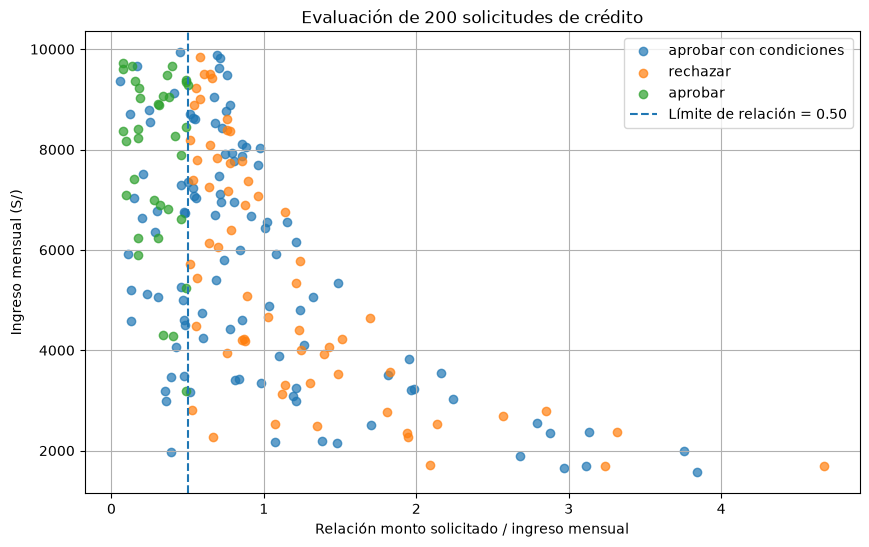

In [6]:
plt.figure(figsize=(10, 6))

# Graficar cada decisión con un marcador diferente
for accion in df_creditos["accion"].unique():

    datos = df_creditos[
        df_creditos["accion"] == accion
    ]

    plt.scatter(
        datos["relacion"],
        datos["ingreso_mensual"],
        label=accion,
        alpha=0.7
    )

# Línea que representa el límite de relación = 0.50
plt.axvline(
    x=0.50,
    linestyle="--",
    label="Límite de relación = 0.50"
)

plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Evaluación de 200 solicitudes de crédito")

plt.legend()
plt.grid(True)

plt.show()

Interpretación de la visualización

El gráfico representa las 200 solicitudes de crédito simuladas. El eje X muestra la relación entre el monto solicitado y el ingreso mensual, mientras que el eje Y representa el ingreso mensual del cliente.

La línea vertical ubicada en 0.50 representa el límite utilizado por las reglas del agente. Las solicitudes ubicadas por encima de este valor tienen una relación monto/ingreso elevada y son evaluadas adicionalmente según el historial moroso.

La distribución de los puntos permite observar cómo el agente clasifica las solicitudes en aprobar, aprobar con condiciones y rechazar, de acuerdo con las condiciones establecidas